### Workflow

1. load estimation window
2. estimate α and β using OLS
3. load event window
4. compute expected return
5. compute abnormal return
6. compute CAR

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

expected_return = mean_return_estimation

In [38]:
def load_data():

    estimation = pd.read_csv("../../data/processed/estimation_window.csv")
    events = pd.read_csv("../../data/processed/events_window.csv")
    market = pd.read_csv("../../data/raw/market_data.csv")

    # surity check for datetime
    estimation["date"] = pd.to_datetime(estimation["date"])
    events["date"] = pd.to_datetime(events["date"])
    market["date"] = pd.to_datetime(market["Date"])

    return estimation, events, market

In [39]:
# Parameter estimation
# α = mean return during estimation window
def estimate_parameters(estimation):

    alpha = (
        estimation
        .groupby("event_id")["sp500_log_return"]
        .mean()
        .reset_index()
    )

    alpha.rename(columns={"sp500_log_return": "alpha"}, inplace=True)

    return alpha

In [40]:
# Abnormal return calculation
def compute_abnormal_returns(events, alpha):

    events = events.merge(alpha, on="event_id", how="left")

    events["abnormal_return"] = (
        events["sp500_log_return"] - events["alpha"]
    )

    events["CAR"] = (
        events
        .groupby("event_id")["abnormal_return"]
        .cumsum()
    )

    return events

In [41]:
# get different CAR windows
def compute_car_windows(events):

    car_3 = (
        events[events["t"] <= 3]
        .groupby("event_id")["abnormal_return"]
        .sum()
        .reset_index(name="CAR_0_3")
    )

    car_10 = (
        events[events["t"] <= 10]
        .groupby("event_id")["abnormal_return"]
        .sum()
        .reset_index(name="CAR_0_10")
    )

    car_30 = (
        events[events["t"] <= 30]
        .groupby("event_id")["abnormal_return"]
        .sum()
        .reset_index(name="CAR_0_30")
    )

    car = car_3.merge(car_10, on="event_id")
    car = car.merge(car_30, on="event_id")

    return car

In [42]:
# VIX-based excess volatility
def compute_vix_volatility(estimation, events):

    baseline_vix = (
        estimation
        .groupby("event_id")["vix"]
        .mean()
        .reset_index(name="vix_baseline")
    )

    event_vix = (
        events[events["t"] <= 3]
        .groupby("event_id")["vix"]
        .mean()
        .reset_index(name="vix_event")
    )

    vix = baseline_vix.merge(event_vix, on="event_id")

    vix["excess_vix"] = (
        vix["vix_event"] - vix["vix_baseline"]
    )

    return vix


In [43]:
# Realized volatility
def compute_realized_volatility(market, events):

    market["rv20"] = (
        market["sp500_log_return"]
        .rolling(20)
        .std()
    )

    events = events.merge(
        market[["date", "rv20"]],
        on="date",
        how="left"
    )

    rv_event = (
        events[events["t"] <= 20]
        .groupby("event_id")["rv20"]
        .mean()
        .reset_index(name="rv_event")
    )

    rv_baseline = (
        events[(events["t"] >= -65) & (events["t"] <= -20)]
        .groupby("event_id")["rv20"]
        .mean()
        .reset_index(name="rv_baseline")
    )

    rv = rv_event.merge(rv_baseline, on="event_id", how="left")

    rv["excess_realized_vol"] = (
        rv["rv_event"] - rv["rv_baseline"]
    )

    return rv



In [44]:
# Temporal alignment indicators
def create_event_indicators(events):

    events["post_event"] = (events["t"] >= 0).astype(int)

    events["immediate_window"] = (
        (events["t"] >= 0) & (events["t"] <= 3)
    ).astype(int)

    events["short_window"] = (
        (events["t"] >= 0) & (events["t"] <= 10)
    ).astype(int)

    events["medium_window"] = (
        (events["t"] >= 0) & (events["t"] <= 30)
    ).astype(int)

    return events


In [45]:
# Visualization
def plot_event_study(events):

    avg_ar = (
        events
        .groupby("t")["abnormal_return"]
        .mean()
    )

    avg_car = (
        events
        .groupby("t")["CAR"]
        .mean()
    )

    plt.figure()
    avg_ar.plot()
    plt.axvline(0)
    plt.title("Average Abnormal Return Around Fed Events")
    plt.xlabel("Event Time (t)")
    plt.ylabel("Average Abnormal Return")
    plt.savefig("../../outputs/avg_ar.png", dpi=300, bbox_inches='tight')

    plt.figure()
    avg_car.plot()
    plt.axvline(0)
    plt.title("Average Cumulative Abnormal Return")
    plt.xlabel("Event Time (t)")
    plt.ylabel("Average CAR")
    plt.savefig("../../outputs/avg_car.png", dpi=300, bbox_inches='tight')

    plt.show()


In [46]:
# Save results
def save_results(events, car, vix, rv):

    results = car.merge(vix, on="event_id", how="left")
    results = results.merge(rv, on="event_id", how="left")

    results.to_csv(
        "../../data/processed/event_study_results.csv",
        index=False
    )

    events.to_csv(
        "../../data/processed/events_with_ar.csv",
        index=False
    )


In [47]:
# Main pipeline
def calc_abnormal_returns():

    print("Loading datasets...")
    estimation, events, market = load_data()

    print("Estimating parameters...")
    alpha = estimate_parameters(estimation)

    print("Computing abnormal returns...")
    events = compute_abnormal_returns(events, alpha)

    print("Calculating CAR windows...")
    car = compute_car_windows(events)

    print("Computing VIX volatility response...")
    vix = compute_vix_volatility(estimation, events)

    print("Computing realized volatility...")
    rv = compute_realized_volatility(market, events)

    print("Creating event indicators...")
    events = create_event_indicators(events)

    print("Generating event study plots...")
    plot_event_study(events)

    print("Saving results...")
    save_results(events, car, vix, rv)

    print("Event study analysis completed.")



Loading datasets...
Estimating parameters...
Computing abnormal returns...
Calculating CAR windows...
Computing VIX volatility response...
Computing realized volatility...
Creating event indicators...
Generating event study plots...


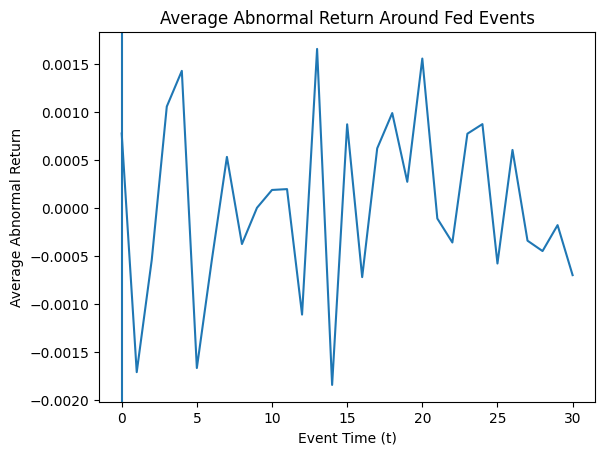

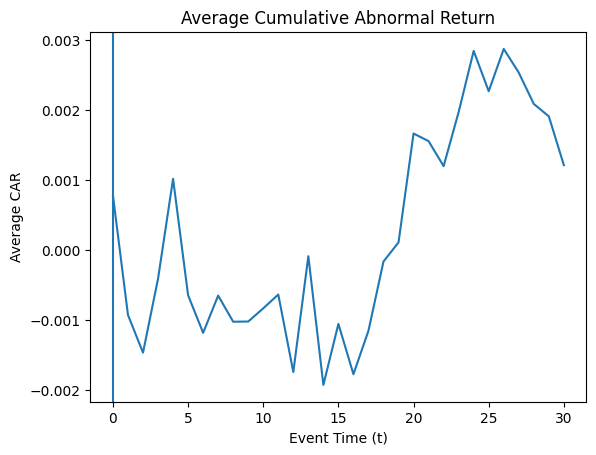

Saving results...
Event study analysis completed.


In [48]:
calc_abnormal_returns()